In [24]:

def getEta(x):
     # enrichment percent
    x = x/100
    sigmaF235 = 507 # 235 fission cross section
    sigmaC235 = 87 # 235 capture cross section
    sigmaC238 = 2.4
    nu235 = 2.4 # average fast neutrons per fission
    etaOverEta235 = 0
    eta235 = nu235 * (sigmaF235)/(sigmaF235+sigmaC235)
    eta = nu235 * (x*sigmaF235)/((x*(sigmaF235+sigmaC235))+((1-x)*sigmaC238))
    return(eta)


In [25]:
x = x/100
sigmaF235 = 507 # 235 fission cross section
sigmaC235 = 87 # 235 capture cross section
sigmaC238 = 2.4
nu235 = 2.4 # average fast neutrons per fission
etaOverEta235 = 0
eta235 = nu235 * (sigmaF235)/(sigmaF235+sigmaC235)
eta = nu235 * (x*sigmaF235)/((x*(sigmaF235+sigmaC235))+((1-x)*sigmaC238))


In [26]:
eta235 = nu235 * (sigmaF235)/(sigmaF235+sigmaC235)
print(eta235)

2.0484848484848484


In [27]:
eta = nu235 * (x*sigmaF235)/((x*(sigmaF235+sigmaC235))+((1-x)*sigmaC238))
print(eta)


2.015499829341257


In [28]:
etaOver5 = eta/eta235
print(etaOver5)

0.9838978456843416


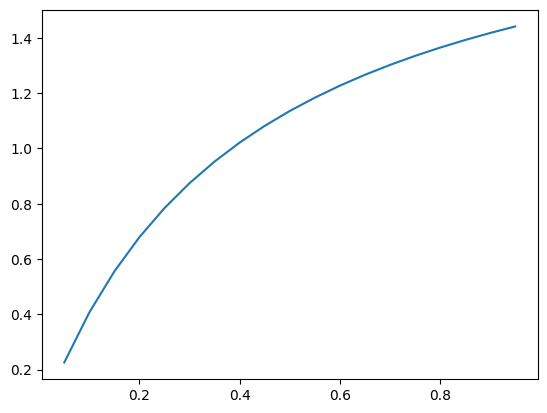

In [29]:
import matplotlib.pyplot as plt
import numpy as np

xpoints = np.array([])
ypoints = np.array([])


for i in range (1,20):
    x = i/20
    getEta(x)
 
    ypoints = np.append(ypoints, getEta(x))
    xpoints = np.append(xpoints, x)

plt.plot(xpoints, ypoints)
plt.show()

In [30]:
print(getEta(5))

1.9024390243902438


In [31]:
#EPR example
eta235 = 2.04848
eta = 1.9
p = 0.88
epsilon = 1.05
x=8.6

conversionRatio = eta235 * epsilon * (1-p) + ((eta235/getEta(x)) - 1)
print(conversionRatio)

0.3010470497903766


In [32]:
initialEnrich = x
finalEnrich = 1.29
conversionRatio = conversionRatio
nucleiFracBurnup = ((initialEnrich - finalEnrich)/100)/(1-conversionRatio)
print(nucleiFracBurnup)

0.10458500815838395


In [41]:
def FracBurnup(x,y):
    # enrichment percent
    initialEnrich = x
    finalEnrich = y
    conversionRatio1 = eta235 * epsilon * (1-p) + ((eta235/getEta(x)) - 1)
    nucleiFracBurnup = ((initialEnrich - finalEnrich)/100)/(1-conversionRatio1)
    return(nucleiFracBurnup)
           
           #,conversionRatio1)

In [56]:
def FracBurnupAndCR(x,y):
    # enrichment percent
    initialEnrich = x
    finalEnrich = y
    conversionRatio1 = eta235 * epsilon * (1-p) + ((eta235/getEta(x)) - 1)
    nucleiFracBurnup = ((initialEnrich - finalEnrich)/100)/(1-conversionRatio1)
    return(nucleiFracBurnup, conversionRatio1)

In [42]:
print(FracBurnup(8.6,1.29))

0.10458500815838395


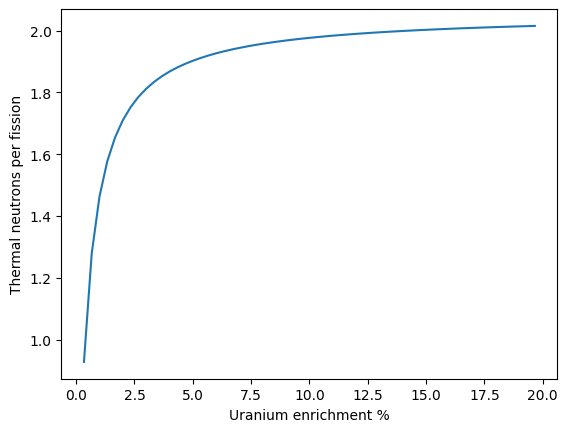

In [43]:
import matplotlib.pyplot as plt
import numpy as np

xpoints = np.array([])
ypoints = np.array([])


for i in range (1,60):
    x = i/3
    getEta(x)
 
    ypoints = np.append(ypoints, getEta(x))
    xpoints = np.append(xpoints, x)

plt.plot(xpoints, ypoints)
plt.xlabel('Uranium enrichment %', fontsize=10)
plt.ylabel('Thermal neutrons per fission', fontsize=10)
plt.show()

In [50]:
def stepFracBurnup(x,y):
    burnups = np.array([])
    a=20
    for i in range(a):
        enrichGap = x - y
        enrichStep = enrichGap/a
        x1 = (x - (i*enrichStep))
        y1 = (x - ((i+1)*enrichStep))
        fracBurnup1 = FracBurnup(x1,y1)
        burnups = np.append(burnups,fracBurnup1)
        steppedBurnup = np.sum(burnups)
    return(steppedBurnup)

In [51]:
print(FracBurnup(8.6,1.29))
print(stepFracBurnup(8.6,1.29))

0.10458500815838395
0.11378681683608154


In [57]:
x=8.6
y=1.29

burnups = np.array([])
a=20

for i in range(a):
    enrichGap = x - y
    enrichStep = enrichGap/a
    x1 = (x - (i*enrichStep))
    y1 = (x - ((i+1)*enrichStep))
    fracBurnup1 = FracBurnupAndCR(x1,y1)[0]
    cr1 = FracBurnupAndCR(x1,y1)[1]
    print('cr = ' + str(cr1))

    burnups = np.append(burnups,fracBurnup1)
    print('x1 = '+ str(x1))
    print('y1 = '+ str(y1))
    print('fracBurn = '+ str(fracBurnup1))
print(burnups)
steppedBurnup = np.sum(burnups)
singleBurnup = FracBurnup(x,y)
print('singleBurnup = '+ str(singleBurnup))
print('steppedBurnup ='+ str(steppedBurnup))

cr = 0.3010470497903766
x1 = 8.6
y1 = 8.234499999999999
fracBurn = 0.005229250407919209
cr = 0.30313238302598294
x1 = 8.234499999999999
y1 = 7.869
fracBurn = 0.005244898616283769
cr = 0.30541143574249247
x1 = 7.869
y1 = 7.5035
fracBurn = 0.005262107941421516
cr = 0.3079125165173438
x1 = 7.5035
y1 = 7.138
fracBurn = 0.005281124261354445
cr = 0.31066973207034293
x1 = 7.138
y1 = 6.7725
fracBurn = 0.005302247949995683
cr = 0.3137245518417607
x1 = 6.7725
y1 = 6.407
fracBurn = 0.005325849860735861
cr = 0.3171279080971657
x1 = 6.407
y1 = 6.041499999999999
fracBurn = 0.005352393286150105
cr = 0.3209430583478868
x1 = 6.041499999999999
y1 = 5.676
fracBurn = 0.0053824646738866245
cr = 0.32524955370665515
x1 = 5.676
y1 = 5.310499999999999
fracBurn = 0.0054168174620384205
cr = 0.33014884599739963
x1 = 5.310499999999999
y1 = 4.945
fracBurn = 0.005456436072640999
cr = 0.33577238149634164
x1 = 4.945
y1 = 4.5794999999999995
fracBurn = 0.005502631775887045
cr = 0.34229357054910486
x1 = 4.579499999999999

In [53]:
enrichGap = x - y
enrichStep = enrichGap/3
x1 = (x - (i*enrichStep))
y1 = (x - ((i+1)*enrichStep))

In [54]:
print(x1)

8.6


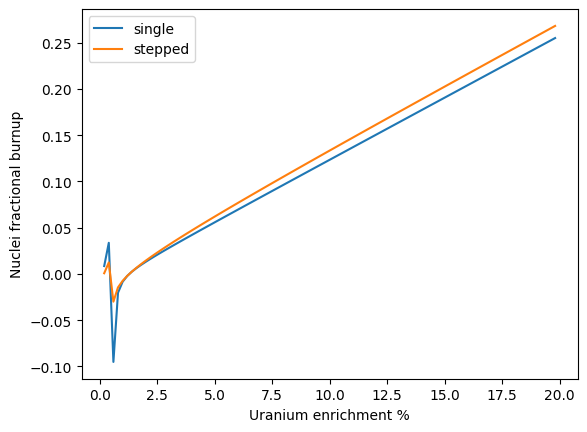

In [61]:
import matplotlib.pyplot as plt
import numpy as np

xpoints = np.array([])
ypoints = np.array([])
ystep = np.array([])

for i in range (1,100):
    x = i/5
    FracBurnup(x,1.29)
    stepFracBurnup(x,1.29)
 
    ypoints = np.append(ypoints, FracBurnupAndCR(x,1.29)[0])
    ystep = np.append(ystep, stepFracBurnup(x,1.29))
    xpoints = np.append(xpoints, x)

plt.plot(xpoints, ypoints, label = 'single')
plt.plot(xpoints, ystep, label = 'stepped')
plt.xlabel('Uranium enrichment %', fontsize=10)
plt.ylabel('Nuclei fractional burnup', fontsize=10)
plt.legend()
plt.show()